<a href="https://colab.research.google.com/github/EmillynPanserini/Analise-de-dados/blob/main/Trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [48]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/analisededados"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Base de dados com registros de pedidos realizados em uma empresa do setor automobilístico. Permite
avaliar o desempenho de vendas, perfis de clientes e padrões de compra.

In [49]:
dicionario_dados = {
    "ORDERNUMBER": "Número de identificação do pedido",
    "QUANTITYORDERED": "Quantidade de itens solicitados",
    "PRICEEACH": "Preço unitário de cada item",
    "ORDERLINENUMBER": "Número da linha dentro do pedido",
    "SALES": "Total da venda",
    "ORDERDATE": "Data do pedido",
    "DAYS_SINCE_LASTORDER": "Dias desde o último pedido do cliente",
    "STATUS": "Status do pedido",
    "PRODUCTLINE": "Categoria do produto",
    "MSRP": "Preço de venda sugerido pelo fabricante",
    "PRODUCTCODE": "Código do produto",
    "CUSTOMERNAME": "Nome do cliente",
    "PHONE": "Telefone do cliente",
    "ADDRESSLINE1": "Endereço do cliente",
    "CITY": "Cidade do cliente",
    "POSTALCODE": "Código postal do cliente",
    "COUNTRY": "País do cliente",
    "CONTACTLASTNAME": "Sobrenome do contato",
    "CONTACTFIRSTNAME": "Nome do contato",
    "DEALSIZE": "Tamanho do pedido"
}

dicionario_df = pd.DataFrame(
    list(dicionario_dados.items()),
    columns=["Coluna", "Descrição"]
)

print("\nDicionário de dados:")
display(dicionario_df)


Dicionário de dados:


,Coluna,Descrição
0,ORDERNUMBER,Número de identificação do pedido
1,QUANTITYORDERED,Quantidade de itens solicitados
2,PRICEEACH,Preço unitário de cada item
3,ORDERLINENUMBER,Número da linha dentro do pedido
4,SALES,Total da venda
5,ORDERDATE,Data do pedido
6,DAYS_SINCE_LASTORDER,Dias desde o último pedido do cliente
7,STATUS,Status do pedido
8,PRODUCTLINE,Categoria do produto
9,MSRP,Preço de venda sugerido pelo fabricante


In [50]:
df = pd.read_csv(f'{path}/08_vendas_automotivas.csv')
df.head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07/05/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01/07/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium
5,10180,29,86.13,9,2497.77,11/11/2018,573,Shipped,Motorcycles,95,S10_1678,Daedalus Designs Imports,20.16.1555,"184, chausse de Tournai",Lille,59000,France,Rance,Martine,Small
6,10188,48,114.84,1,5512.32,18/11/2018,567,Shipped,Motorcycles,95,S10_1678,Herkku Gifts,+47 2267 3215,"Drammen 121, PR 744 Sentrum",Bergen,N 5804,Norway,Oeztan,Veysel,Medium
7,10211,41,114.84,14,4708.44,15/01/2019,510,Shipped,Motorcycles,95,S10_1678,Auto Canal Petit,(1) 47.55.6555,"25, rue Lauriston",Paris,75016,France,Perrier,Dominique,Medium
8,10223,37,107.18,1,3965.66,20/02/2019,475,Shipped,Motorcycles,95,S10_1678,"Australian Collectors, Co.",03 9520 4555,636 St Kilda Road,Melbourne,3004,Australia,Ferguson,Peter,Medium
9,10237,23,101.44,7,2333.12,05/04/2019,432,Shipped,Motorcycles,95,S10_1678,Vitachrome Inc.,2125551500,2678 Kingston Rd.,NYC,10022,USA,Frick,Michael,Small


### Limpeza e preparação dos dados

In [51]:
valores_ausentes = df.isnull().sum().reset_index()
valores_ausentes.columns = ["Coluna", "Quantidade de valores ausentes"]
display(valores_ausentes)

,Coluna,Quantidade de valores ausentes
0,ORDERNUMBER,0
1,QUANTITYORDERED,0
2,PRICEEACH,0
3,ORDERLINENUMBER,0
4,SALES,0
5,ORDERDATE,0
6,DAYS_SINCE_LASTORDER,0
7,STATUS,0
8,PRODUCTLINE,0
9,MSRP,0


In [52]:
print("\nTotal de valores ausentes na base:", df.isnull().sum().sum())


Total de valores ausentes na base: 0


In [53]:
duplicatas = df.duplicated().sum()
print(f"Quantidade de linhas duplicadas: {duplicatas}")

Quantidade de linhas duplicadas: 0


In [54]:
if duplicatas > 0:
    df = df.drop_duplicates()
    print("Duplicatas removidas.")
else:
    print("Nenhuma duplicata encontrada.")

Nenhuma duplicata encontrada.


In [55]:
# Remove espaços extras no início e no fim das colunas textuais
colunas_texto = df.select_dtypes(include=["object"]).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].astype(str).str.strip()

In [56]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"], dayfirst=True, errors="coerce")

print("Tipo da coluna ORDERDATE após conversão:")
print(df["ORDERDATE"].dtype)

print("\nQuantidade de datas inválidas após conversão:")
print(df["ORDERDATE"].isnull().sum())


Tipo da coluna ORDERDATE após conversão:
datetime64[ns]

Quantidade de datas inválidas após conversão:
0


### Criação de colunas temporais

In [57]:
df["ANO"] = df["ORDERDATE"].dt.year
df["MES"] = df["ORDERDATE"].dt.month
df["ANO_MES"] = df["ORDERDATE"].dt.to_period("M").astype(str)
df["DIA_SEMANA"] = df["ORDERDATE"].dt.day_name()

### Conferência do cálculo de vendas

In [58]:
df["SALES_CALCULADO"] = df["QUANTITYORDERED"] * df["PRICEEACH"]
df["DIFERENCA_SALES"] = df["SALES"] - df["SALES_CALCULADO"]

print("Resumo da diferença entre SALES e QUANTITYORDERED * PRICEEACH:")
display(df["DIFERENCA_SALES"].describe())

Resumo da diferença entre SALES e QUANTITYORDERED * PRICEEACH:


,DIFERENCA_SALES
count,2747.000000
mean,-0.000022
std,0.001266
min,-0.040000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.020000


### Resumo geral da base

In [59]:
resumo_geral = {
    "Total de registros": df.shape[0],
    "Total de colunas": df.shape[1],
    "Pedidos únicos": df["ORDERNUMBER"].nunique(),
    "Clientes únicos": df["CUSTOMERNAME"].nunique(),
    "Produtos únicos": df["PRODUCTCODE"].nunique(),
    "Categorias de produto": df["PRODUCTLINE"].nunique(),
    "Países": df["COUNTRY"].nunique(),
    "Cidades": df["CITY"].nunique(),
    "Data inicial": df["ORDERDATE"].min(),
    "Data final": df["ORDERDATE"].max(),
    "Faturamento total": df["SALES"].sum(),
    "Quantidade total vendida": df["QUANTITYORDERED"].sum()
}

resumo_geral_df = pd.DataFrame(
    resumo_geral.items(),
    columns=["Indicador", "Valor"]
)

display(resumo_geral_df)

,Indicador,Valor
0,Total de registros,2747
1,Total de colunas,26
2,Pedidos únicos,298
3,Clientes únicos,89
4,Produtos únicos,109
5,Categorias de produto,7
6,Países,19
7,Cidades,71
8,Data inicial,2018-01-06 00:00:00
9,Data final,2020-05-31 00:00:00


### Análise estatística descritiva

In [60]:
# ESTATÍSTICA DESCRITIVA - VARIÁVEIS NUMÉRICAS

colunas_numericas = [
    "QUANTITYORDERED",
    "PRICEEACH",
    "ORDERLINENUMBER",
    "SALES",
    "DAYS_SINCE_LASTORDER",
    "MSRP"
]

estatistica_descritiva = df[colunas_numericas].describe().T
estatistica_descritiva["mediana"] = df[colunas_numericas].median()
estatistica_descritiva["variancia"] = df[colunas_numericas].var()
estatistica_descritiva["amplitude"] = df[colunas_numericas].max() - df[colunas_numericas].min()

display(estatistica_descritiva)

,count,mean,std,min,25%,50%,75%,max,mediana,variancia,amplitude
QUANTITYORDERED,2747.0,35.103021,9.762135,6.00,27.000,35.00,43.000,97.00,35.00,9.529929e+01,91.00
PRICEEACH,2747.0,101.098952,42.042549,26.88,68.745,95.55,127.100,252.87,95.55,1.767576e+03,225.99
ORDERLINENUMBER,2747.0,6.491081,4.230544,1.00,3.000,6.00,9.000,18.00,6.00,1.789750e+01,17.00
SALES,2747.0,3553.047583,1838.953901,482.13,2204.350,3184.80,4503.095,14082.80,3184.80,3.381751e+06,13600.67
DAYS_SINCE_LASTORDER,2747.0,1757.085912,819.280576,42.00,1077.000,1761.00,2436.500,3562.00,1761.00,6.712207e+05,3520.00
MSRP,2747.0,100.691664,40.114802,33.00,68.000,99.00,124.000,214.00,99.00,1.609197e+03,181.00


In [61]:
# MODA DAS VARIÁVEIS CATEGÓRICAS

colunas_categoricas = [
    "STATUS",
    "PRODUCTLINE",
    "PRODUCTCODE",
    "CUSTOMERNAME",
    "CITY",
    "COUNTRY",
    "DEALSIZE"
]

modas = []

for coluna in colunas_categoricas:
    modas.append({
        "Coluna": coluna,
        "Moda": df[coluna].mode()[0],
        "Frequência": df[coluna].value_counts().iloc[0],
        "Quantidade de categorias únicas": df[coluna].nunique()
    })

modas_df = pd.DataFrame(modas)
display(modas_df)

,Coluna,Moda,Frequência,Quantidade de categorias únicas
0,STATUS,Shipped,2541,6
1,PRODUCTLINE,Classic Cars,949,7
2,PRODUCTCODE,S18_3232,51,109
3,CUSTOMERNAME,Euro Shopping Channel,259,89
4,CITY,Madrid,304,71
5,COUNTRY,USA,928,19
6,DEALSIZE,Medium,1349,3


In [62]:
# ANÁLISE DE FREQUÊNCIA DAS VARIÁVEIS CATEGÓRICAS

for coluna in colunas_categoricas:
    print(f"\nFrequência da coluna: {coluna}")
    display(df[coluna].value_counts().reset_index().rename(
        columns={"index": coluna, coluna: "Frequência"}
    ))


Frequência da coluna: STATUS


,Frequência,count
0,Shipped,2541
1,Cancelled,60
2,Resolved,47
3,On Hold,44
4,In Process,41
5,Disputed,14



Frequência da coluna: PRODUCTLINE


,Frequência,count
0,Classic Cars,949
1,Vintage Cars,579
2,Motorcycles,313
3,Planes,304
4,Trucks and Buses,295
5,Ships,230
6,Trains,77



Frequência da coluna: PRODUCTCODE


...

,Frequência,count
0,Madrid,304
1,San Rafael,180
2,NYC,152
3,Singapore,79
4,Paris,70
...,...,...
66,Graz,15
67,Brisbane,15
68,Munich,14
69,Burbank,13



Frequência da coluna: COUNTRY


,Frequência,count
0,USA,928
1,Spain,342
2,France,314
3,Australia,185
4,UK,144
5,Italy,113
6,Finland,92
7,Norway,85
8,Singapore,79
9,Canada,70



Frequência da coluna: DEALSIZE


,Frequência,count
0,Medium,1349
1,Small,1246
2,Large,152


### Análise de vendas por categoria de produto

In [63]:
vendas_por_categoria = df.groupby("PRODUCTLINE").agg(
    FATURAMENTO_TOTAL=("SALES", "sum"),
    MEDIA_VENDAS=("SALES", "mean"),
    MEDIANA_VENDAS=("SALES", "median"),
    QUANTIDADE_TOTAL=("QUANTITYORDERED", "sum"),
    TOTAL_REGISTROS=("PRODUCTLINE", "count"),
    PEDIDOS_UNICOS=("ORDERNUMBER", "nunique")
).sort_values(by="FATURAMENTO_TOTAL", ascending=False)

display(vendas_por_categoria)

,FATURAMENTO_TOTAL,MEDIA_VENDAS,MEDIANA_VENDAS,QUANTIDADE_TOTAL,TOTAL_REGISTROS,PEDIDOS_UNICOS
PRODUCTLINE,,,,,,
Classic Cars,3842868.54,4049.387292,3754.050,33373,949,193
Vintage Cars,1806675.68,3120.337962,2795.270,20059,579,169
Trucks and Buses,1111559.19,3767.997254,3451.000,10579,295,71
Motorcycles,1103512.19,3525.598051,3153.600,11080,313,70
Planes,969323.42,3188.563882,2841.805,10636,304,58
Ships,700039.22,3043.648783,2884.925,7989,230,63
Trains,226243.47,2938.226883,2445.600,2712,77,45


### Gráfico de barras - faturamento por categoria

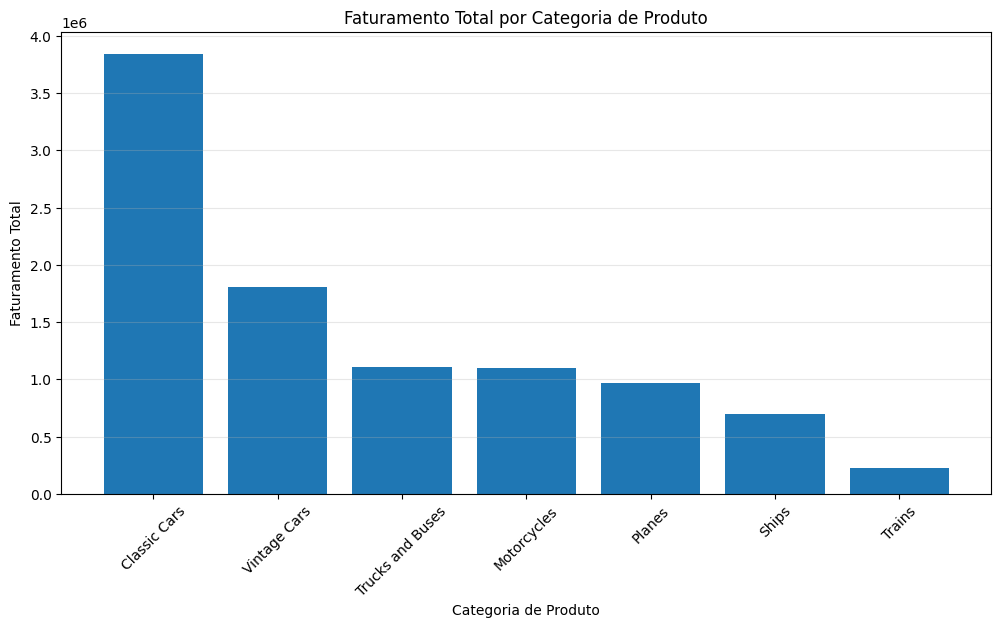

In [64]:
plt.figure(figsize=(12, 6))
plt.bar(vendas_por_categoria.index, vendas_por_categoria["FATURAMENTO_TOTAL"])
plt.title("Faturamento Total por Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Gráfico de barras - quantidade vendida por categoria

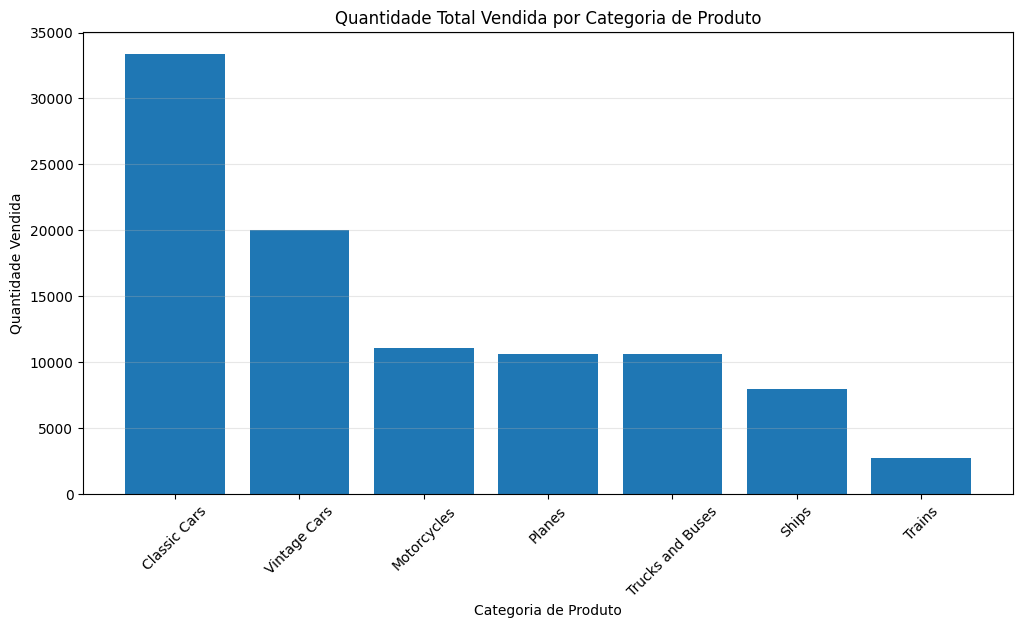

In [65]:
quantidade_por_categoria = df.groupby("PRODUCTLINE")["QUANTITYORDERED"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(quantidade_por_categoria.index, quantidade_por_categoria.values)
plt.title("Quantidade Total Vendida por Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Análise de vendas por país

In [66]:
vendas_por_pais = df.groupby("COUNTRY").agg(
    FATURAMENTO_TOTAL=("SALES", "sum"),
    MEDIA_VENDAS=("SALES", "mean"),
    QUANTIDADE_TOTAL=("QUANTITYORDERED", "sum"),
    CLIENTES_UNICOS=("CUSTOMERNAME", "nunique"),
    PEDIDOS_UNICOS=("ORDERNUMBER", "nunique")
).sort_values(by="FATURAMENTO_TOTAL", ascending=False)

display(vendas_por_pais)

,FATURAMENTO_TOTAL,MEDIA_VENDAS,QUANTIDADE_TOTAL,CLIENTES_UNICOS,PEDIDOS_UNICOS
COUNTRY,,,,,
USA,3355575.69,3615.922080,33020,32,103
Spain,1215686.92,3554.640117,12429,5,36
France,1110916.52,3537.950701,11090,12,37
Australia,630623.10,3408.773514,6246,5,19
UK,478880.46,3325.558750,5013,5,13
Italy,374674.31,3315.701858,3773,3,8
Finland,329581.91,3582.412065,3192,3,9
Norway,307463.70,3617.220000,2842,3,9
Singapore,288488.41,3651.752025,2760,2,9


### Gráfico de barras - top 10 países por faturamento

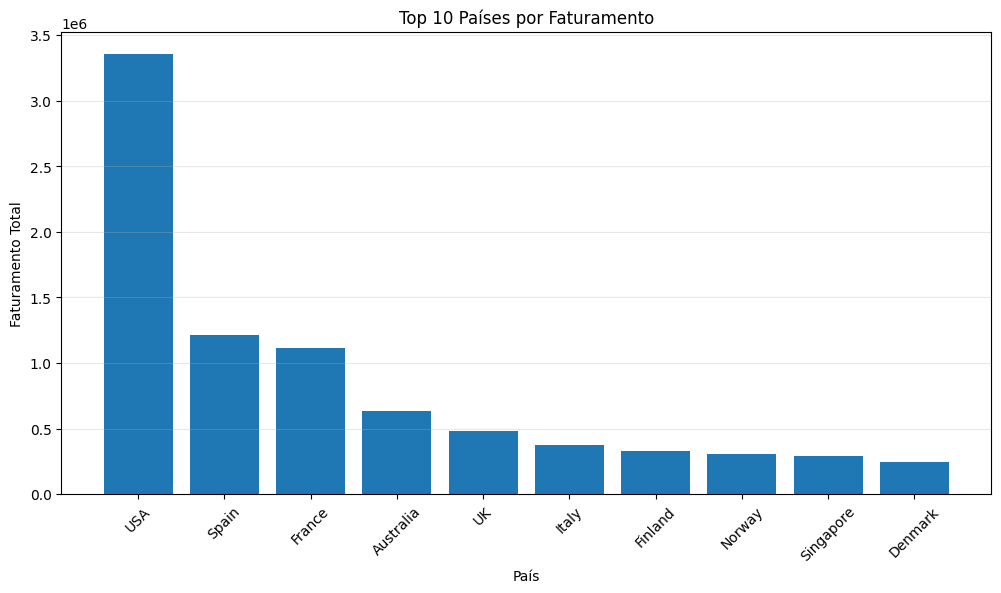

In [67]:
top_10_paises = vendas_por_pais.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_paises.index, top_10_paises["FATURAMENTO_TOTAL"])
plt.title("Top 10 Países por Faturamento")
plt.xlabel("País")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Análise de vendas por cliente

In [68]:
vendas_por_cliente = df.groupby("CUSTOMERNAME").agg(
    FATURAMENTO_TOTAL=("SALES", "sum"),
    MEDIA_COMPRA=("SALES", "mean"),
    MEDIANA_COMPRA=("SALES", "median"),
    QUANTIDADE_TOTAL=("QUANTITYORDERED", "sum"),
    PEDIDOS_UNICOS=("ORDERNUMBER", "nunique"),
    CATEGORIAS_COMPRADAS=("PRODUCTLINE", "nunique"),
    DIAS_MEDIOS_DESDE_ULTIMO_PEDIDO=("DAYS_SINCE_LASTORDER", "mean")
).sort_values(by="FATURAMENTO_TOTAL", ascending=False)

display(vendas_por_cliente)


,FATURAMENTO_TOTAL,MEDIA_COMPRA,MEDIANA_COMPRA,QUANTIDADE_TOTAL,PEDIDOS_UNICOS,CATEGORIAS_COMPRADAS,DIAS_MEDIOS_DESDE_ULTIMO_PEDIDO
CUSTOMERNAME,,,,,,,
Euro Shopping Channel,912294.11,3522.371081,3177.910,9327,26,7,1791.092664
Mini Gifts Distributors Ltd.,654858.06,3638.100333,3358.545,6366,17,6,1655.561111
"Australian Collectors, Co.",200995.41,3654.462000,3199.860,1926,5,5,1698.781818
Muscle Machine Inc,197736.94,4119.519583,3934.620,1775,4,4,1743.479167
La Rochelle Gifts,180124.90,3398.583019,3164.800,1832,4,6,1828.433962
...,...,...,...,...,...,...,...
Royale Belge,33440.10,4180.012500,4867.145,278,4,5,1498.000000
Microscale Inc.,33144.93,3314.493000,3014.940,381,2,3,1856.700000
Auto-Moto Classics Inc.,26479.26,3309.907500,3001.555,287,3,3,2281.750000


### Gráfico de barras - top 10 clientes por faturamento

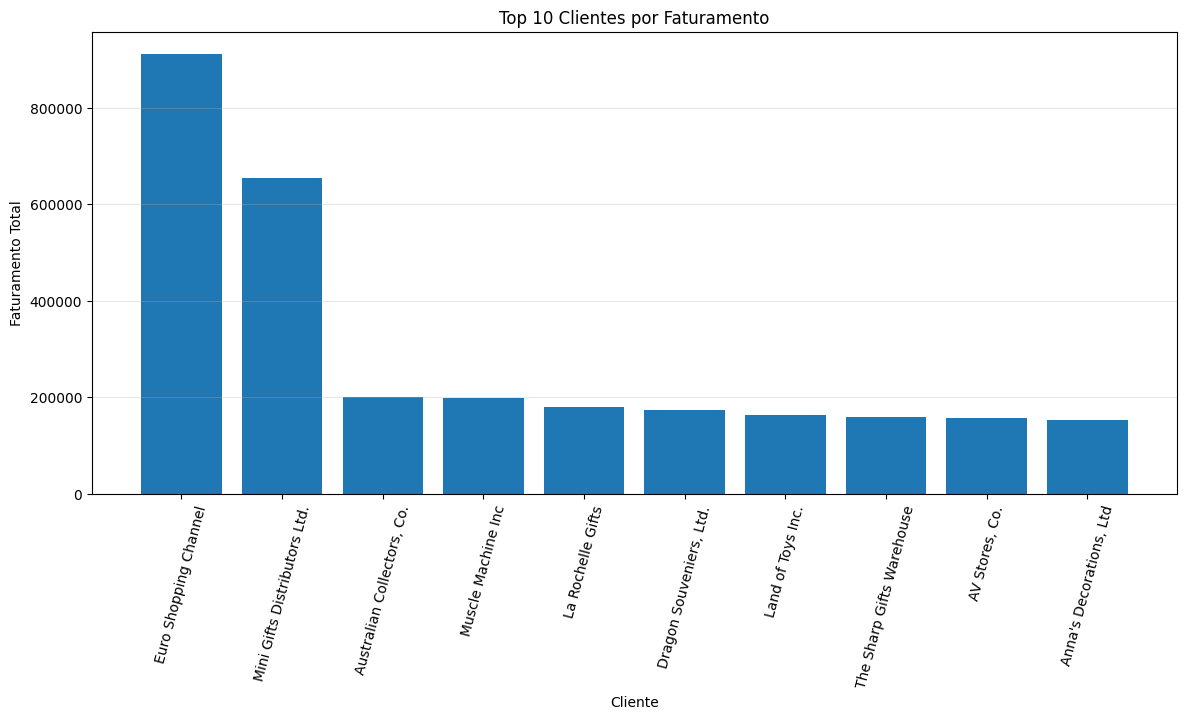

In [69]:
top_10_clientes = vendas_por_cliente.head(10)

plt.figure(figsize=(14, 6))
plt.bar(top_10_clientes.index, top_10_clientes["FATURAMENTO_TOTAL"])
plt.title("Top 10 Clientes por Faturamento")
plt.xlabel("Cliente")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=75)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Análise do tamanho do pedido

In [70]:
analise_dealsize = df.groupby("DEALSIZE").agg(
    FATURAMENTO_TOTAL=("SALES", "sum"),
    MEDIA_VENDAS=("SALES", "mean"),
    MEDIANA_VENDAS=("SALES", "median"),
    QUANTIDADE_TOTAL=("QUANTITYORDERED", "sum"),
    TOTAL_REGISTROS=("DEALSIZE", "count"),
    PEDIDOS_UNICOS=("ORDERNUMBER", "nunique"),
    MEDIA_DIAS_DESDE_ULTIMO_PEDIDO=("DAYS_SINCE_LASTORDER", "mean")
).sort_values(by="FATURAMENTO_TOTAL", ascending=False)

display(analise_dealsize)

,FATURAMENTO_TOTAL,MEDIA_VENDAS,MEDIANA_VENDAS,QUANTIDADE_TOTAL,TOTAL_REGISTROS,PEDIDOS_UNICOS,MEDIA_DIAS_DESDE_ULTIMO_PEDIDO
DEALSIZE,,,,,,,
Medium,5931231.47,4396.761653,4149.070,51209,1349,283,1630.498888
Small,2570033.84,2062.627480,2113.975,38025,1246,278,1981.402889
Large,1258956.40,8282.607895,7972.400,7194,152,114,1041.736842


Gráfico de barras - faturamento por tamanho do pedido

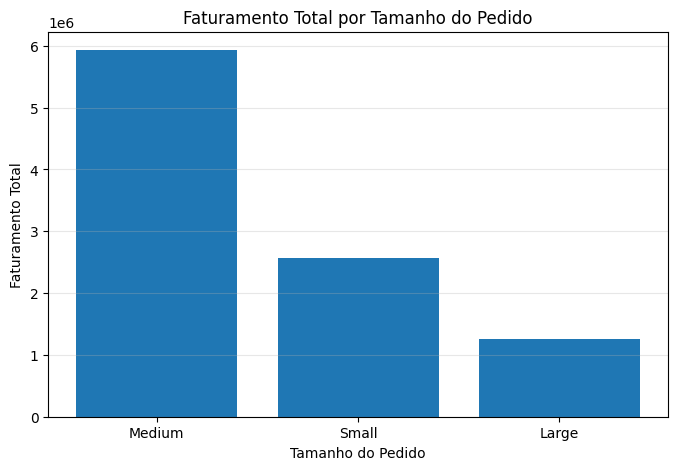

In [71]:
plt.figure(figsize=(8, 5))
plt.bar(analise_dealsize.index, analise_dealsize["FATURAMENTO_TOTAL"])
plt.title("Faturamento Total por Tamanho do Pedido")
plt.xlabel("Tamanho do Pedido")
plt.ylabel("Faturamento Total")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Análise do status dos pedidos

In [72]:
analise_status = df.groupby("STATUS").agg(
    FATURAMENTO_TOTAL=("SALES", "sum"),
    TOTAL_REGISTROS=("STATUS", "count"),
    PEDIDOS_UNICOS=("ORDERNUMBER", "nunique"),
    MEDIA_VENDAS=("SALES", "mean")
).sort_values(by="TOTAL_REGISTROS", ascending=False)

display(analise_status)

,FATURAMENTO_TOTAL,TOTAL_REGISTROS,PEDIDOS_UNICOS,MEDIA_VENDAS
STATUS,,,,
Shipped,9019093.94,2541,277,3549.426974
Cancelled,194487.48,60,4,3241.458000
Resolved,150718.28,47,4,3206.771915
On Hold,178979.19,44,4,4067.708864
In Process,144729.96,41,6,3529.999024
Disputed,72212.86,14,3,5158.061429


### Gráfico de barras - status do pedido

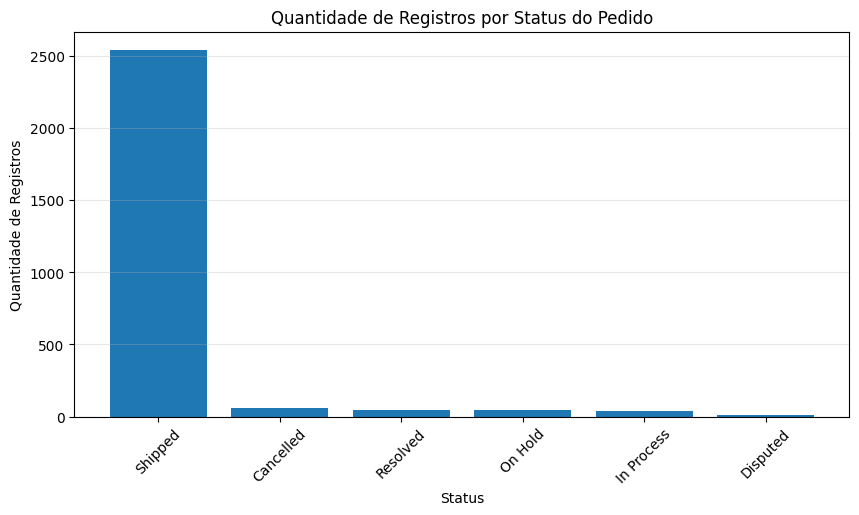

In [73]:
plt.figure(figsize=(10, 5))
plt.bar(analise_status.index, analise_status["TOTAL_REGISTROS"])
plt.title("Quantidade de Registros por Status do Pedido")
plt.xlabel("Status")
plt.ylabel("Quantidade de Registros")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Histogramas - distribuição das variáveis numéricas

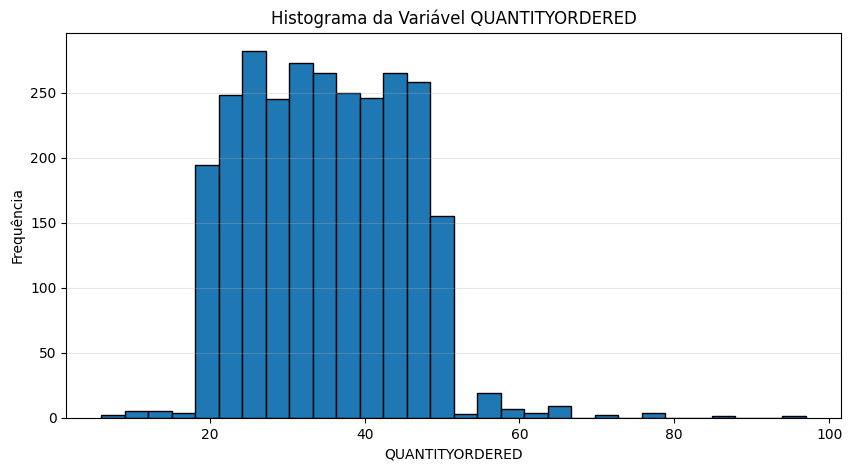

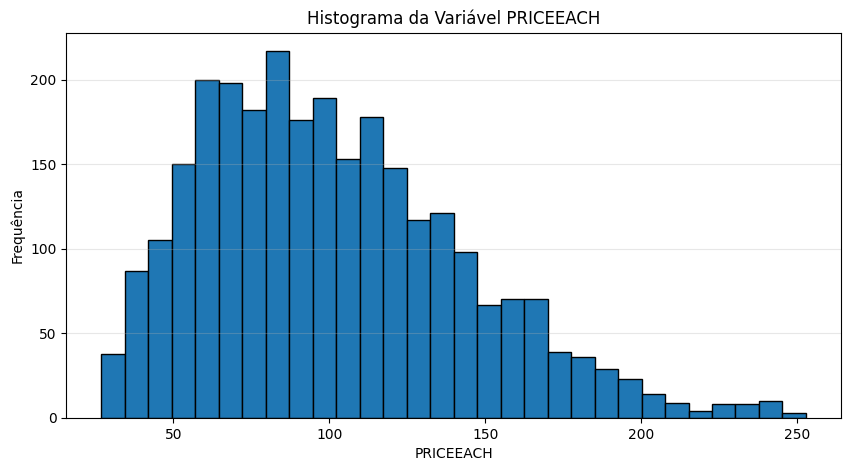

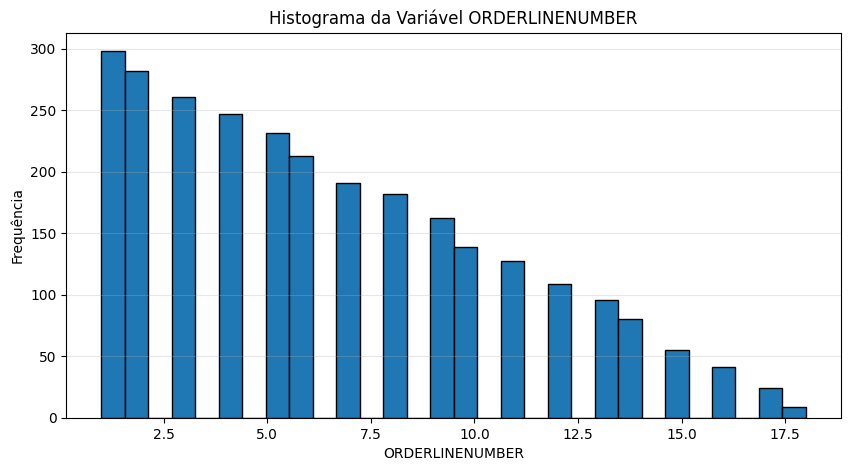

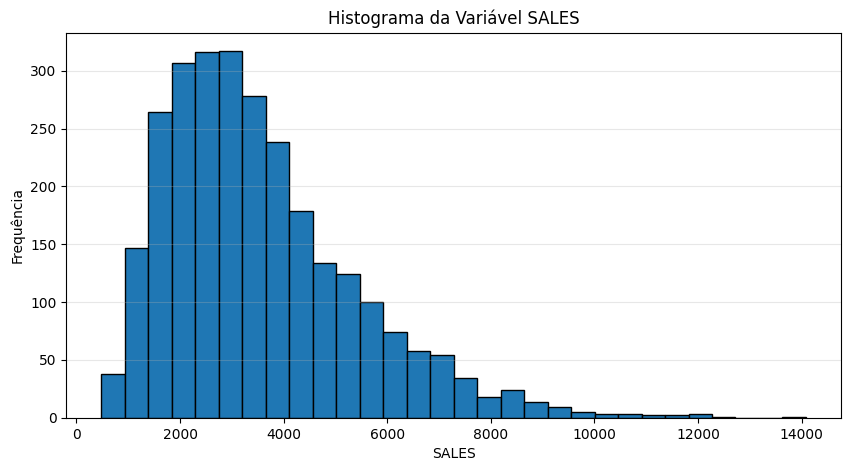

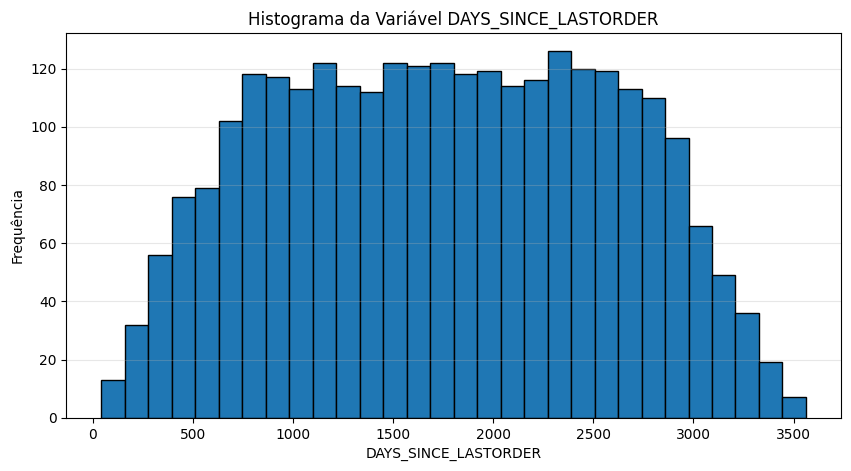

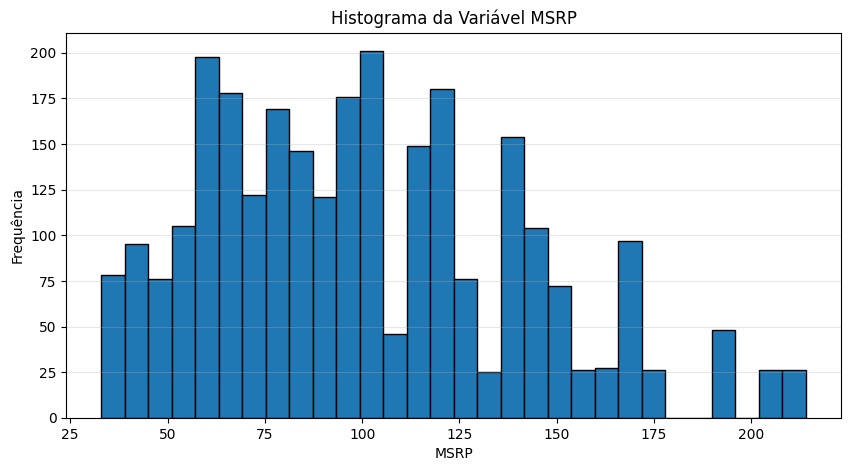

In [74]:
for coluna in colunas_numericas:
    plt.figure(figsize=(10, 5))
    plt.hist(df[coluna], bins=30, edgecolor="black")
    plt.title(f"Histograma da Variável {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

Boxplots - detecção visual de outliers

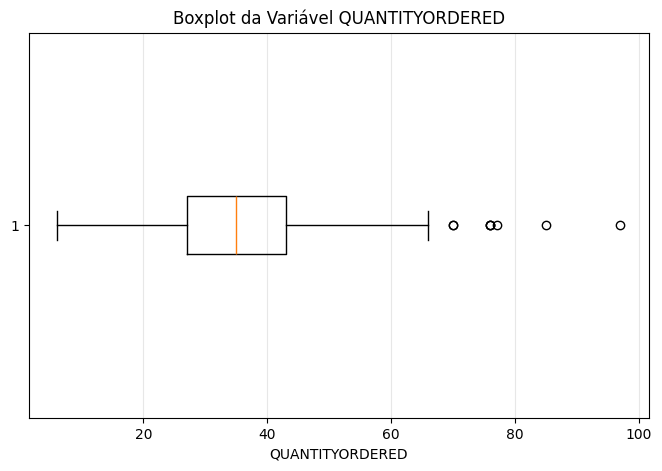

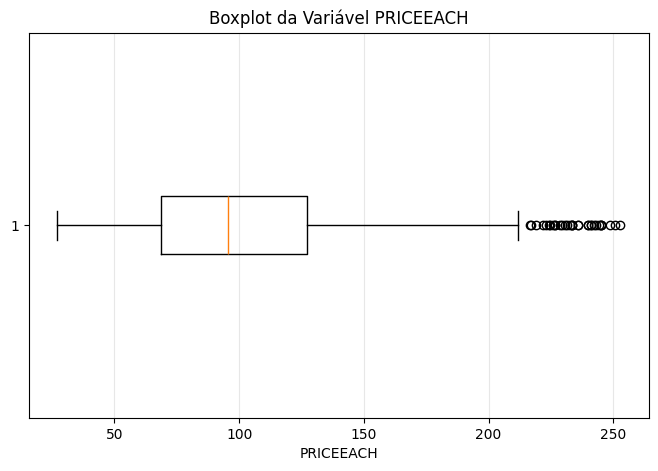

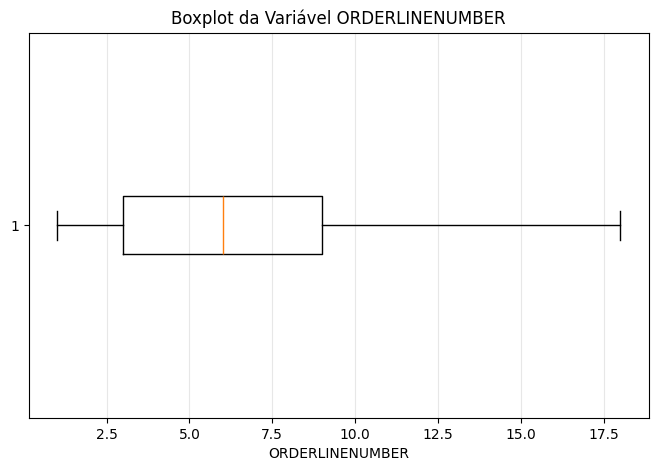

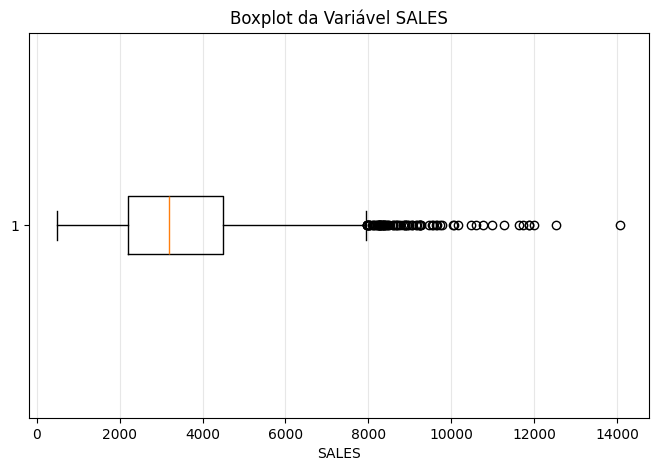

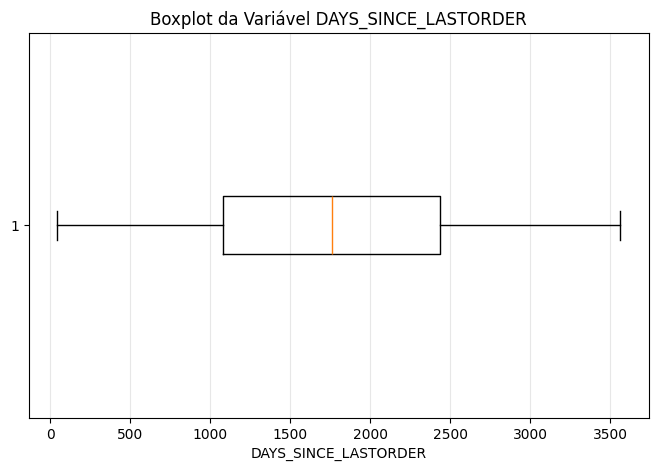

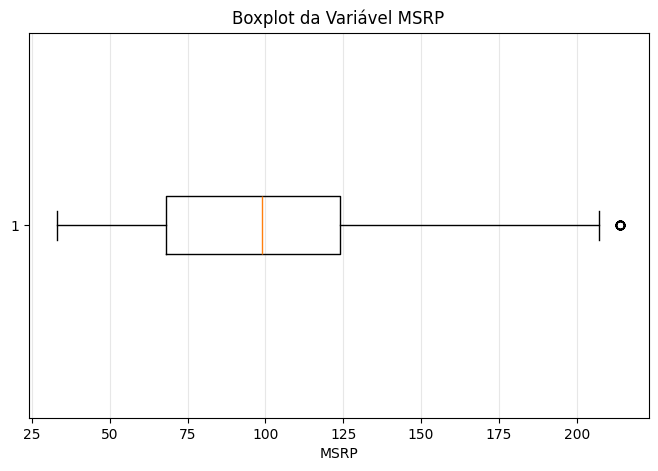

In [75]:
for coluna in colunas_numericas:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[coluna], vert=False)
    plt.title(f"Boxplot da Variável {coluna}")
    plt.xlabel(coluna)
    plt.grid(axis="x", alpha=0.3)
    plt.show()

Boxplot de sales por categoria de produto

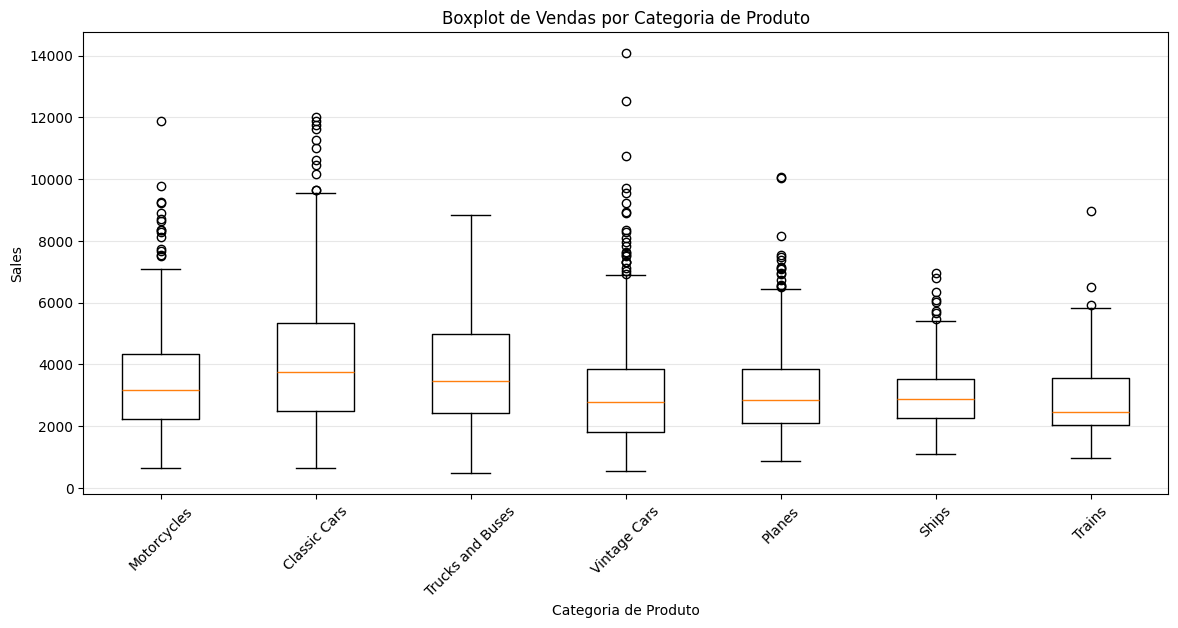

In [95]:
categorias = df["PRODUCTLINE"].unique()

dados_boxplot = [
    df[df["PRODUCTLINE"] == categoria]["SALES"]
    for categoria in categorias
]

plt.figure(figsize=(14, 6))
plt.boxplot(dados_boxplot, tick_labels=categorias)
plt.title("Boxplot de Vendas por Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


Boxplot de sales por tamanho do pedido

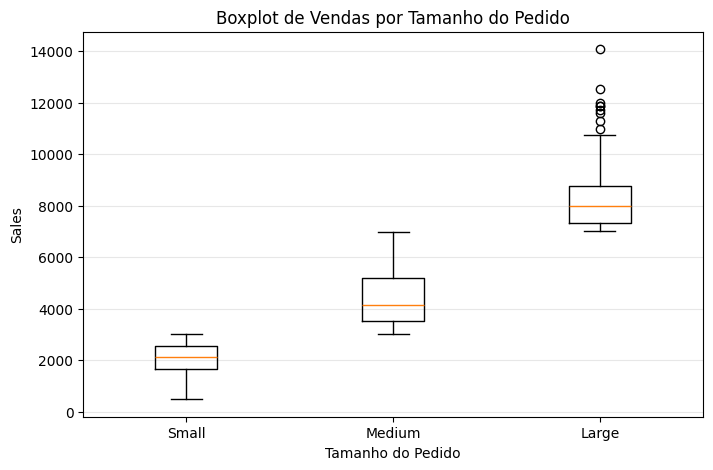

In [96]:
tamanhos = df["DEALSIZE"].unique()

dados_boxplot_dealsize = [
    df[df["DEALSIZE"] == tamanho]["SALES"]
    for tamanho in tamanhos
]

plt.figure(figsize=(8, 5))
plt.boxplot(dados_boxplot_dealsize, tick_labels=tamanhos)
plt.title("Boxplot de Vendas por Tamanho do Pedido")
plt.xlabel("Tamanho do Pedido")
plt.ylabel("Sales")
plt.grid(axis="y", alpha=0.3)
plt.show()

Análise temporal - vendas ao longo do tempo

In [78]:
vendas_mensais = df.groupby("ANO_MES").agg(
    FATURAMENTO_TOTAL=("SALES", "sum"),
    MEDIA_VENDAS=("SALES", "mean"),
    QUANTIDADE_TOTAL=("QUANTITYORDERED", "sum"),
    PEDIDOS_UNICOS=("ORDERNUMBER", "nunique")
).reset_index()

display(vendas_mensais)

,ANO_MES,FATURAMENTO_TOTAL,MEDIA_VENDAS,QUANTIDADE_TOTAL,PEDIDOS_UNICOS
0,2018-01,129753.60,3327.015385,1357,5
1,2018-02,140836.19,3435.029024,1449,3
2,2018-03,155809.32,3541.120909,1538,5
3,2018-04,201609.55,3476.026724,1993,7
4,2018-05,192673.11,3321.950172,2017,6
5,2018-06,168082.56,3653.968696,1649,6
6,2018-07,187731.88,3754.637600,1725,6
7,2018-08,197809.30,3410.505172,1974,5
8,2018-09,263973.36,3473.333684,2510,8
9,2018-10,448452.95,3616.556048,4308,14


Gráficos de linhas - faturamento ao logo do tempo

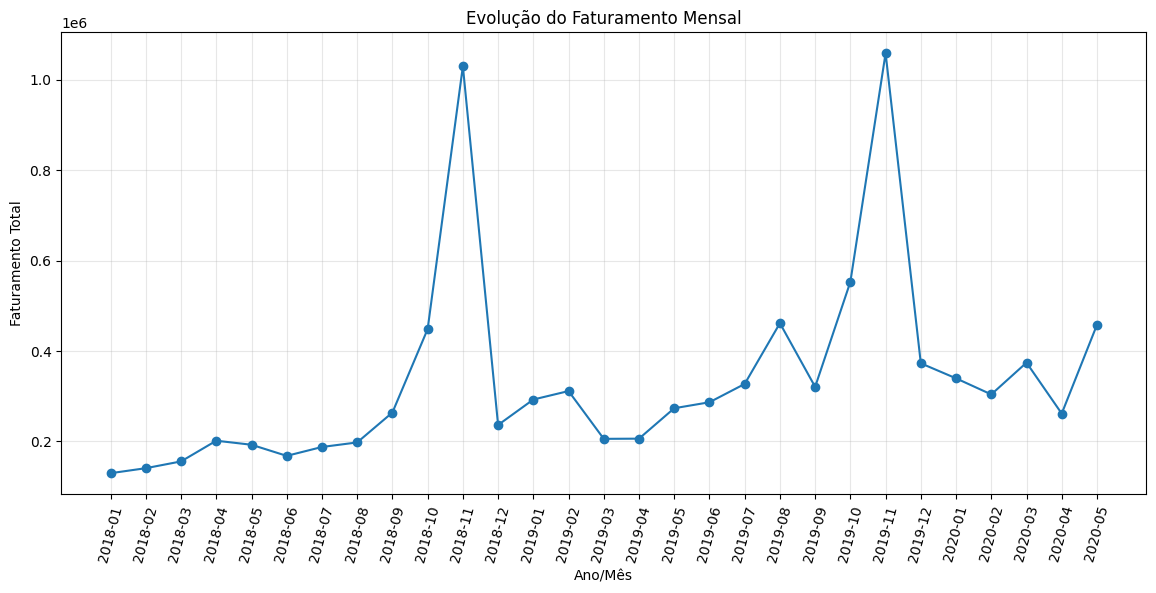

In [79]:
plt.figure(figsize=(14, 6))
plt.plot(vendas_mensais["ANO_MES"], vendas_mensais["FATURAMENTO_TOTAL"], marker="o")
plt.title("Evolução do Faturamento Mensal")
plt.xlabel("Ano/Mês")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=75)
plt.grid(alpha=0.3)
plt.show()

Gráfico de linhas - pedidos únicos ao longo do tempo

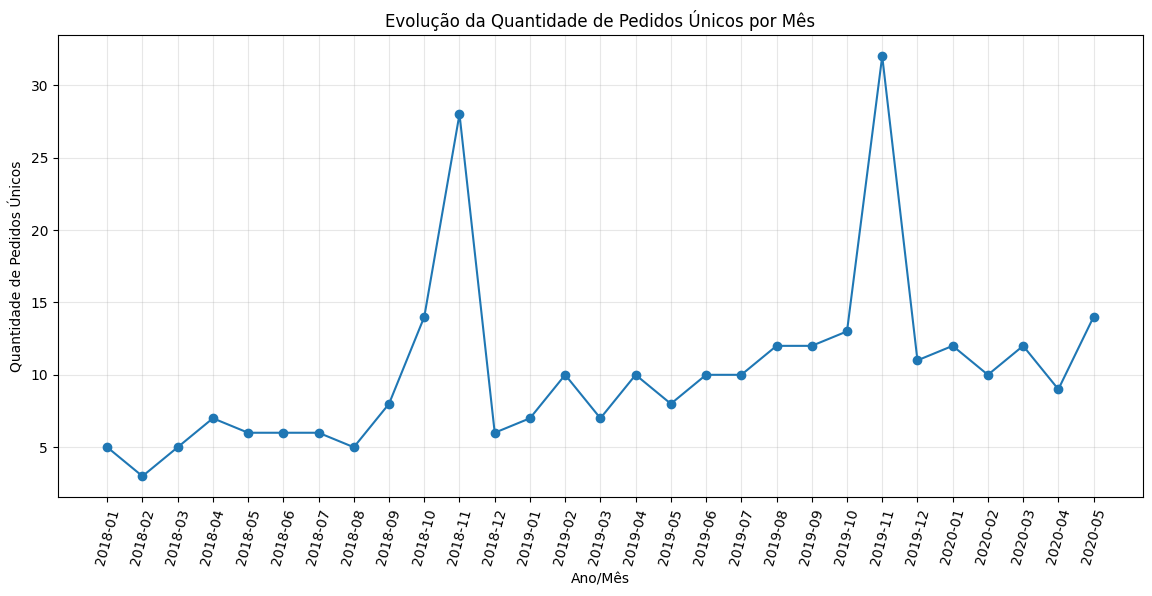

In [80]:
plt.figure(figsize=(14, 6))
plt.plot(vendas_mensais["ANO_MES"], vendas_mensais["PEDIDOS_UNICOS"], marker="o")
plt.title("Evolução da Quantidade de Pedidos Únicos por Mês")
plt.xlabel("Ano/Mês")
plt.ylabel("Quantidade de Pedidos Únicos")
plt.xticks(rotation=75)
plt.grid(alpha=0.3)
plt.show()

### Relação entre dias desde o último pedido de vendas

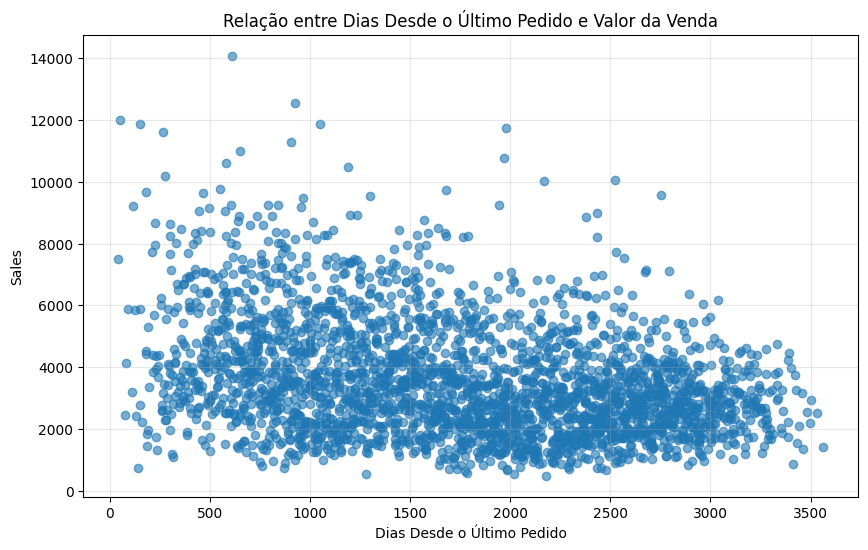

In [81]:
plt.figure(figsize=(10, 6))
plt.scatter(df["DAYS_SINCE_LASTORDER"], df["SALES"], alpha=0.6)
plt.title("Relação entre Dias Desde o Último Pedido e Valor da Venda")
plt.xlabel("Dias Desde o Último Pedido")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

Relação entre preço unitário e vendas

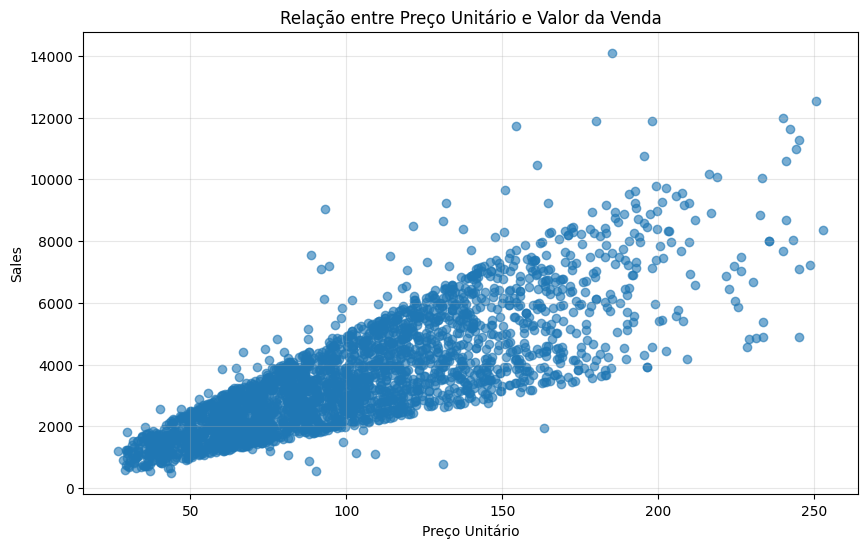

In [82]:
plt.figure(figsize=(10, 6))
plt.scatter(df["PRICEEACH"], df["SALES"], alpha=0.6)
plt.title("Relação entre Preço Unitário e Valor da Venda")
plt.xlabel("Preço Unitário")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

### Relação entre quantidade pedida e vendas

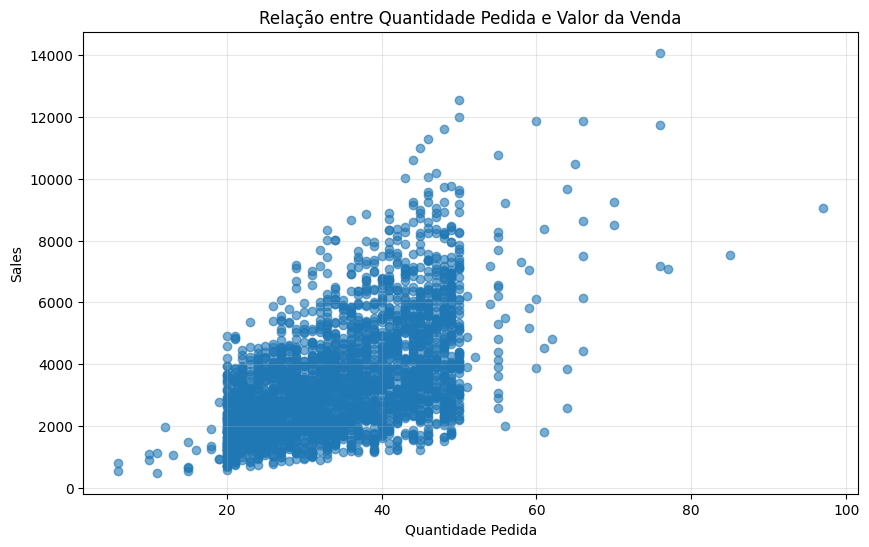

In [83]:
plt.figure(figsize=(10, 6))
plt.scatter(df["QUANTITYORDERED"], df["SALES"], alpha=0.6)
plt.title("Relação entre Quantidade Pedida e Valor da Venda")
plt.xlabel("Quantidade Pedida")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()


### Correlação entre variáveis numéricas

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,DAYS_SINCE_LASTORDER,MSRP
QUANTITYORDERED,1.000000,0.010161,-0.016295,0.553359,-0.021923,0.020551
PRICEEACH,0.010161,1.000000,-0.052646,0.808287,-0.397091,0.778393
ORDERLINENUMBER,-0.016295,-0.052646,1.000000,-0.057414,0.046615,-0.020956
SALES,0.553359,0.808287,-0.057414,1.000000,-0.334274,0.634849
DAYS_SINCE_LASTORDER,-0.021923,-0.397091,0.046615,-0.334274,1.000000,-0.524285
MSRP,0.020551,0.778393,-0.020956,0.634849,-0.524285,1.000000


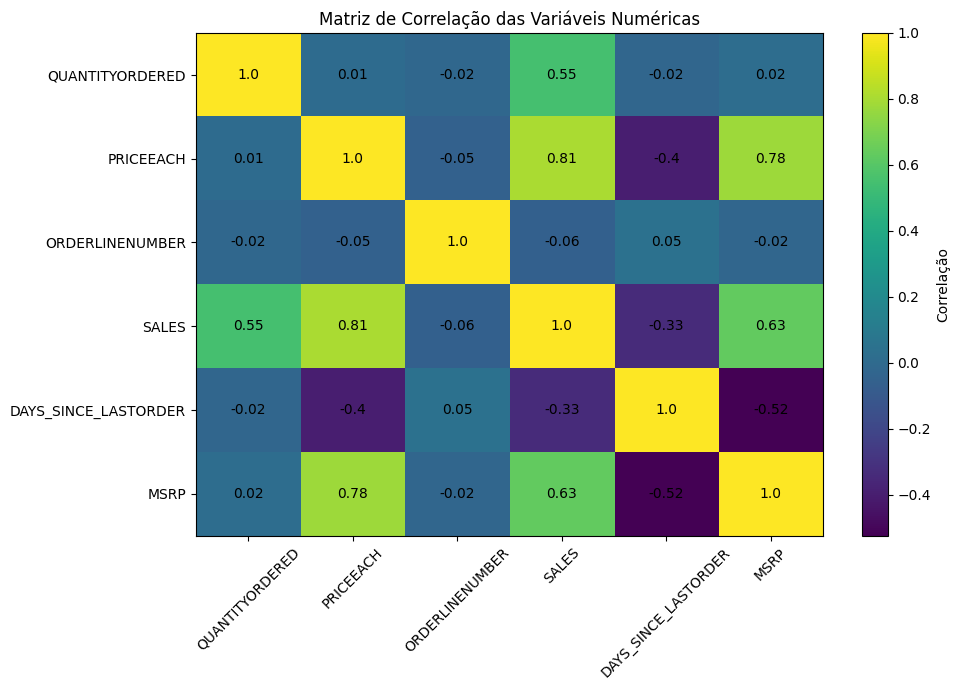

In [84]:
correlacao = df[colunas_numericas].corr()

display(correlacao)

plt.figure(figsize=(10, 7))
plt.imshow(correlacao, cmap="viridis", aspect="auto")
plt.colorbar(label="Correlação")
plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=45)
plt.yticks(range(len(correlacao.index)), correlacao.index)

for i in range(len(correlacao.index)):
    for j in range(len(correlacao.columns)):
        plt.text(j, i, round(correlacao.iloc[i, j], 2),
                 ha="center", va="center")

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.tight_layout()
plt.show()

Detecção de outliers pelo método IQR

In [85]:
 # Detecta outliers usando o método do intervalo interquartil.

def detectar_outliers_iqr(dataframe, coluna):

    q1 = dataframe[coluna].quantile(0.25)
    q3 = dataframe[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[coluna] < limite_inferior) |
        (dataframe[coluna] > limite_superior)
    ]

    return {
        "Coluna": coluna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior,
        "Quantidade de outliers": outliers.shape[0],
        "Percentual de outliers": round((outliers.shape[0] / dataframe.shape[0]) * 100, 2)
    }


outliers_resultado = []

for coluna in colunas_numericas:
    outliers_resultado.append(detectar_outliers_iqr(df, coluna))

outliers_df = pd.DataFrame(outliers_resultado)

display(outliers_df)

,Coluna,Q1,Q3,IQR,Limite inferior,Limite superior,Quantidade de outliers,Percentual de outliers
0,QUANTITYORDERED,27.000,43.000,16.000,3.0000,67.0000,8,0.29
1,PRICEEACH,68.745,127.100,58.355,-18.7875,214.6325,33,1.20
2,ORDERLINENUMBER,3.000,9.000,6.000,-6.0000,18.0000,0,0.00
3,SALES,2204.350,4503.095,2298.745,-1243.7675,7951.2125,79,2.88
4,DAYS_SINCE_LASTORDER,1077.000,2436.500,1359.500,-962.2500,4475.7500,0,0.00
5,MSRP,68.000,124.000,56.000,-16.0000,208.0000,26,0.95


Clientes com maior potencial financeiro

In [86]:
# Critérios usados:
# - Maior faturamento total
# - Maior quantidade comprada
# - Maior número de pedidos únicos
# - Maior diversidade de categorias compradas

clientes_potenciais = vendas_por_cliente.copy()

clientes_potenciais["RANK_FATURAMENTO"] = clientes_potenciais["FATURAMENTO_TOTAL"].rank(ascending=False)
clientes_potenciais["RANK_QUANTIDADE"] = clientes_potenciais["QUANTIDADE_TOTAL"].rank(ascending=False)
clientes_potenciais["RANK_PEDIDOS"] = clientes_potenciais["PEDIDOS_UNICOS"].rank(ascending=False)
clientes_potenciais["RANK_CATEGORIAS"] = clientes_potenciais["CATEGORIAS_COMPRADAS"].rank(ascending=False)

clientes_potenciais["PONTUACAO_POTENCIAL"] = (
    clientes_potenciais["RANK_FATURAMENTO"] +
    clientes_potenciais["RANK_QUANTIDADE"] +
    clientes_potenciais["RANK_PEDIDOS"] +
    clientes_potenciais["RANK_CATEGORIAS"]
)

clientes_potenciais = clientes_potenciais.sort_values(
    by="PONTUACAO_POTENCIAL",
    ascending=True
)

display(clientes_potenciais.head(15))


CLIENTES COM MAIOR POTENCIAL FINANCEIRO


,FATURAMENTO_TOTAL,MEDIA_COMPRA,MEDIANA_COMPRA,QUANTIDADE_TOTAL,PEDIDOS_UNICOS,CATEGORIAS_COMPRADAS,DIAS_MEDIOS_DESDE_ULTIMO_PEDIDO,RANK_FATURAMENTO,RANK_QUANTIDADE,RANK_PEDIDOS,RANK_CATEGORIAS,PONTUACAO_POTENCIAL
CUSTOMERNAME,,,,,,,,,,,,
Euro Shopping Channel,912294.11,3522.371081,3177.910,9327,26,7,1791.092664,1.0,1.0,1.0,2.5,5.5
Mini Gifts Distributors Ltd.,654858.06,3638.100333,3358.545,6366,17,6,1655.561111,2.0,2.0,2.0,10.0,16.0
"Dragon Souveniers, Ltd.",172989.68,4023.015814,3551.340,1524,5,6,1840.534884,6.0,11.0,4.5,10.0,31.5
Land of Toys Inc.,164069.44,3348.355918,3053.700,1631,4,7,1615.469388,7.0,9.0,14.0,2.5,32.5
La Rochelle Gifts,180124.90,3398.583019,3164.800,1832,4,6,1828.433962,5.0,4.0,14.0,10.0,33.0
Reims Collectables,135042.94,3293.730244,3042.410,1433,5,7,1840.609756,17.0,14.0,4.5,2.5,38.0
"Australian Collectors, Co.",200995.41,3654.462000,3199.860,1926,5,5,1698.781818,3.0,3.0,4.5,28.5,39.0
Souveniers And Things Co.,151570.98,3295.021304,3185.710,1601,4,6,1681.847826,11.0,10.0,14.0,10.0,45.0
The Sharp Gifts Warehouse,160010.27,4000.256750,3056.150,1656,4,5,1756.375000,8.0,7.0,14.0,28.5,57.5


### Produtos com maior faturamento

In [87]:
produtos_faturamento = df.groupby("PRODUCTCODE").agg(
    FATURAMENTO_TOTAL=("SALES", "sum"),
    MEDIA_VENDAS=("SALES", "mean"),
    QUANTIDADE_TOTAL=("QUANTITYORDERED", "sum"),
    TOTAL_REGISTROS=("PRODUCTCODE", "count"),
    PRODUCTLINE=("PRODUCTLINE", "first")
).sort_values(by="FATURAMENTO_TOTAL", ascending=False)

display(produtos_faturamento.head(15))

,FATURAMENTO_TOTAL,MEDIA_VENDAS,QUANTIDADE_TOTAL,TOTAL_REGISTROS,PRODUCTLINE
PRODUCTCODE,,,,,
S18_3232,284249.02,5573.510196,1754,51,Classic Cars
S10_1949,179815.23,6915.970385,899,26,Classic Cars
S12_1108,168585.32,6484.050769,973,26,Classic Cars
S10_4698,158202.48,6591.770000,850,24,Motorcycles
S18_2238,154623.95,5726.812963,966,27,Classic Cars
S12_3891,145332.04,5589.693846,921,26,Classic Cars
S18_1662,139421.97,5362.383462,940,26,Planes
S24_3856,135859.20,5225.353846,1017,26,Classic Cars
S18_4027,133779.35,5145.359615,922,26,Classic Cars


Gráfico de barras - top 10 produtos por faturamento

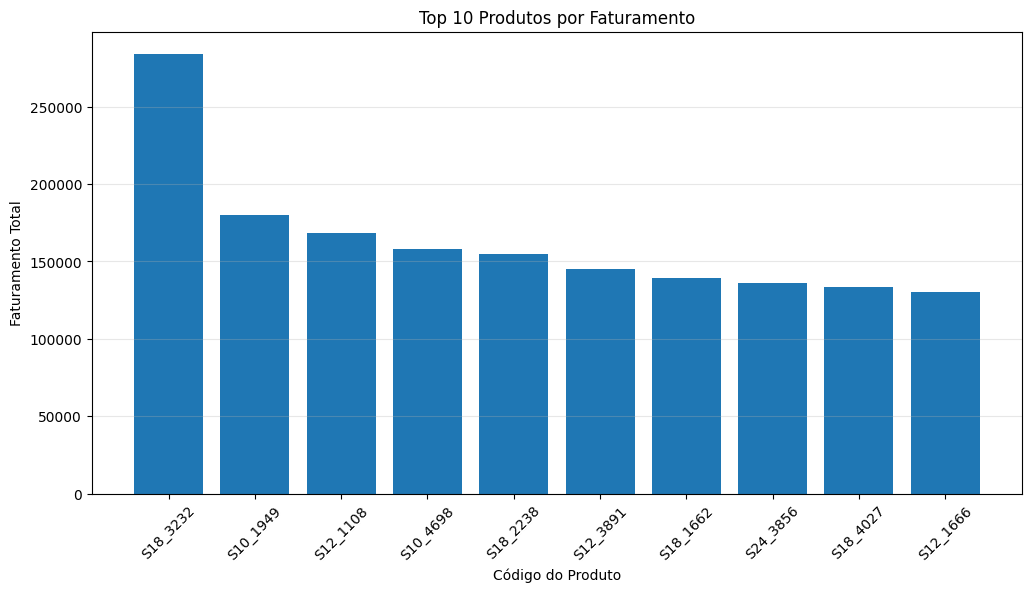

In [88]:
top_10_produtos = produtos_faturamento.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_produtos.index, top_10_produtos["FATURAMENTO_TOTAL"])
plt.title("Top 10 Produtos por Faturamento")
plt.xlabel("Código do Produto")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

Análise entre tempo desde último pedido e tamanho do negócio

,MEDIA_DIAS_DESDE_ULTIMO_PEDIDO,MEDIANA_DIAS_DESDE_ULTIMO_PEDIDO,MEDIA_SALES,MEDIANA_SALES,FATURAMENTO_TOTAL,TOTAL_REGISTROS
DEALSIZE,,,,,,
Small,1981.402889,2042.0,2062.627480,2113.975,2570033.84,1246
Medium,1630.498888,1541.0,4396.761653,4149.070,5931231.47,1349
Large,1041.736842,910.5,8282.607895,7972.400,1258956.40,152


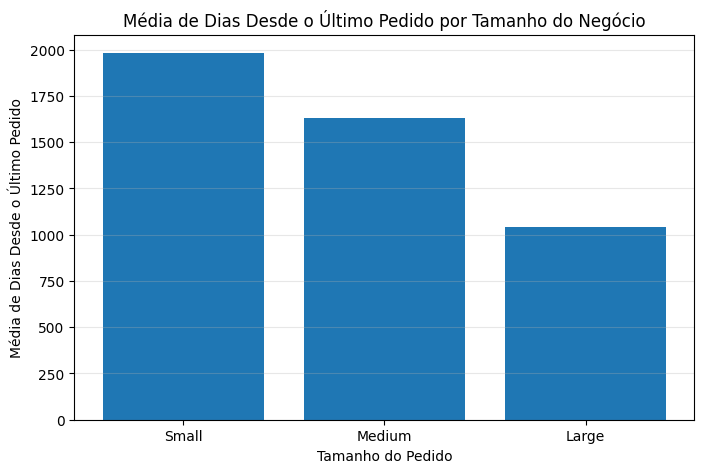

In [89]:
tempo_por_dealsize = df.groupby("DEALSIZE").agg(
    MEDIA_DIAS_DESDE_ULTIMO_PEDIDO=("DAYS_SINCE_LASTORDER", "mean"),
    MEDIANA_DIAS_DESDE_ULTIMO_PEDIDO=("DAYS_SINCE_LASTORDER", "median"),
    MEDIA_SALES=("SALES", "mean"),
    MEDIANA_SALES=("SALES", "median"),
    FATURAMENTO_TOTAL=("SALES", "sum"),
    TOTAL_REGISTROS=("DEALSIZE", "count")
).sort_values(by="MEDIA_DIAS_DESDE_ULTIMO_PEDIDO", ascending=False)

display(tempo_por_dealsize)


plt.figure(figsize=(8, 5))
plt.bar(tempo_por_dealsize.index, tempo_por_dealsize["MEDIA_DIAS_DESDE_ULTIMO_PEDIDO"])
plt.title("Média de Dias Desde o Último Pedido por Tamanho do Negócio")
plt.xlabel("Tamanho do Pedido")
plt.ylabel("Média de Dias Desde o Último Pedido")
plt.grid(axis="y", alpha=0.3)
plt.show()


Resumo final

In [90]:
categoria_maior_faturamento = vendas_por_categoria.index[0]
pais_maior_faturamento = vendas_por_pais.index[0]
cliente_maior_faturamento = vendas_por_cliente.index[0]
dealsize_mais_frequente = df["DEALSIZE"].mode()[0]
status_mais_frequente = df["STATUS"].mode()[0]
produto_maior_faturamento = produtos_faturamento.index[0]

print(f"Total de registros analisados: {df.shape[0]}")
print(f"Período analisado: {df['ORDERDATE'].min().date()} até {df['ORDERDATE'].max().date()}")
print(f"Faturamento total da base: {df['SALES'].sum():,.2f}")
print(f"Quantidade total vendida: {df['QUANTITYORDERED'].sum():,.0f}")
print(f"Categoria com maior faturamento: {categoria_maior_faturamento}")
print(f"País com maior faturamento: {pais_maior_faturamento}")
print(f"Cliente com maior faturamento: {cliente_maior_faturamento}")
print(f"Produto com maior faturamento: {produto_maior_faturamento}")
print(f"Tamanho de pedido mais frequente: {dealsize_mais_frequente}")
print(f"Status mais frequente dos pedidos: {status_mais_frequente}")


Total de registros analisados: 2747
Período analisado: 2018-01-06 até 2020-05-31
Faturamento total da base: 9,760,221.71
Quantidade total vendida: 96,428
Categoria com maior faturamento: Classic Cars
País com maior faturamento: USA
Cliente com maior faturamento: Euro Shopping Channel
Produto com maior faturamento: S18_3232
Tamanho de pedido mais frequente: Medium
Status mais frequente dos pedidos: Shipped


In [91]:
print("\n1. Resumo geral")
display(resumo_geral_df)

print("\n2. Estatística descritiva")
display(estatistica_descritiva)

print("\n3. Vendas por categoria")
display(vendas_por_categoria)

print("\n4. Vendas por país")
display(vendas_por_pais)

print("\n5. Top 15 clientes com maior potencial financeiro")
display(clientes_potenciais.head(15))

print("\n6. Top 15 produtos com maior faturamento")
display(produtos_faturamento.head(15))

print("\n7. Análise por tamanho do pedido")
display(analise_dealsize)

print("\n8. Outliers")
display(outliers_df)


1. Resumo geral


,Indicador,Valor
0,Total de registros,2747
1,Total de colunas,26
2,Pedidos únicos,298
3,Clientes únicos,89
4,Produtos únicos,109
5,Categorias de produto,7
6,Países,19
7,Cidades,71
8,Data inicial,2018-01-06 00:00:00
9,Data final,2020-05-31 00:00:00



2. Estatística descritiva


,count,mean,std,min,25%,50%,75%,max,mediana,variancia,amplitude
QUANTITYORDERED,2747.0,35.103021,9.762135,6.00,27.000,35.00,43.000,97.00,35.00,9.529929e+01,91.00
PRICEEACH,2747.0,101.098952,42.042549,26.88,68.745,95.55,127.100,252.87,95.55,1.767576e+03,225.99
ORDERLINENUMBER,2747.0,6.491081,4.230544,1.00,3.000,6.00,9.000,18.00,6.00,1.789750e+01,17.00
SALES,2747.0,3553.047583,1838.953901,482.13,2204.350,3184.80,4503.095,14082.80,3184.80,3.381751e+06,13600.67
DAYS_SINCE_LASTORDER,2747.0,1757.085912,819.280576,42.00,1077.000,1761.00,2436.500,3562.00,1761.00,6.712207e+05,3520.00
MSRP,2747.0,100.691664,40.114802,33.00,68.000,99.00,124.000,214.00,99.00,1.609197e+03,181.00



3. Vendas por categoria


...

,FATURAMENTO_TOTAL,MEDIA_VENDAS,QUANTIDADE_TOTAL,TOTAL_REGISTROS,PRODUCTLINE
PRODUCTCODE,,,,,
S18_3232,284249.02,5573.510196,1754,51,Classic Cars
S10_1949,179815.23,6915.970385,899,26,Classic Cars
S12_1108,168585.32,6484.050769,973,26,Classic Cars
S10_4698,158202.48,6591.770000,850,24,Motorcycles
S18_2238,154623.95,5726.812963,966,27,Classic Cars
S12_3891,145332.04,5589.693846,921,26,Classic Cars
S18_1662,139421.97,5362.383462,940,26,Planes
S24_3856,135859.20,5225.353846,1017,26,Classic Cars
S18_4027,133779.35,5145.359615,922,26,Classic Cars



7. Análise por tamanho do pedido


,FATURAMENTO_TOTAL,MEDIA_VENDAS,MEDIANA_VENDAS,QUANTIDADE_TOTAL,TOTAL_REGISTROS,PEDIDOS_UNICOS,MEDIA_DIAS_DESDE_ULTIMO_PEDIDO
DEALSIZE,,,,,,,
Medium,5931231.47,4396.761653,4149.070,51209,1349,283,1630.498888
Small,2570033.84,2062.627480,2113.975,38025,1246,278,1981.402889
Large,1258956.40,8282.607895,7972.400,7194,152,114,1041.736842



8. Outliers


,Coluna,Q1,Q3,IQR,Limite inferior,Limite superior,Quantidade de outliers,Percentual de outliers
0,QUANTITYORDERED,27.000,43.000,16.000,3.0000,67.0000,8,0.29
1,PRICEEACH,68.745,127.100,58.355,-18.7875,214.6325,33,1.20
2,ORDERLINENUMBER,3.000,9.000,6.000,-6.0000,18.0000,0,0.00
3,SALES,2204.350,4503.095,2298.745,-1243.7675,7951.2125,79,2.88
4,DAYS_SINCE_LASTORDER,1077.000,2436.500,1359.500,-962.2500,4475.7500,0,0.00
5,MSRP,68.000,124.000,56.000,-16.0000,208.0000,26,0.95


In [92]:
texto_conclusao = f"""
A análise da Base 08 - Vendas Automotivas considerou {df.shape[0]} registros,
{df['ORDERNUMBER'].nunique()} pedidos únicos, {df['CUSTOMERNAME'].nunique()} clientes
e {df['PRODUCTLINE'].nunique()} categorias de produtos.

O período analisado vai de {df['ORDERDATE'].min().date()} até {df['ORDERDATE'].max().date()}.
O faturamento total registrado na base foi de {df['SALES'].sum():,.2f}, com uma
quantidade total vendida de {df['QUANTITYORDERED'].sum():,.0f} itens.

A categoria de produto com maior faturamento foi {categoria_maior_faturamento}.
O país com maior faturamento foi {pais_maior_faturamento}.
O cliente com maior faturamento foi {cliente_maior_faturamento}.
O produto com maior faturamento foi {produto_maior_faturamento}.

A análise por tamanho do pedido indicou que o tamanho mais frequente foi {dealsize_mais_frequente}.
Além disso, o status mais frequente dos pedidos foi {status_mais_frequente}.

Com base nos resultados, a empresa pode direcionar ações comerciais para os clientes
com maior potencial financeiro, fortalecer as categorias de produtos com melhor desempenho
e investigar os padrões temporais de vendas para apoiar decisões estratégicas de estoque,
marketing e relacionamento com clientes.
"""

print(texto_conclusao)



A análise da Base 08 - Vendas Automotivas considerou 2747 registros,
298 pedidos únicos, 89 clientes
e 7 categorias de produtos.

O período analisado vai de 2018-01-06 até 2020-05-31.
O faturamento total registrado na base foi de 9,760,221.71, com uma
quantidade total vendida de 96,428 itens.

A categoria de produto com maior faturamento foi Classic Cars.
O país com maior faturamento foi USA.
O cliente com maior faturamento foi Euro Shopping Channel.
O produto com maior faturamento foi S18_3232.

A análise por tamanho do pedido indicou que o tamanho mais frequente foi Medium.
Além disso, o status mais frequente dos pedidos foi Shipped.

Com base nos resultados, a empresa pode direcionar ações comerciais para os clientes
com maior potencial financeiro, fortalecer as categorias de produtos com melhor desempenho
e investigar os padrões temporais de vendas para apoiar decisões estratégicas de estoque,
marketing e relacionamento com clientes.

